# Estudo de ablação — tarefas binárias (4 grupos)

Hipocampo L/R × T1/T2/T3 (features absolutas, sem deltas).

| Task | Classes |
|------|---------|
| `cn_ad` | CN (0) vs AD (1) |
| `smci_pmci` | sMCI (0) vs pMCI (1) |
| `cn_smci` | CN (0) vs sMCI (1) |
| `smci_ad` | sMCI (0) vs AD (1) |
| `cn_pmci` | CN (0) vs pMCI (1) |
| `pmci_ad` | pMCI (0) vs AD (1) |

Presets em `TASK_PRESETS`: `core` (2 within), `cross` (4 cross), `all` (6).

**Modalidades** (`csvs/longitudinal_4_groups/ablation/{roi}/`):

| ID | CSV long | Conteúdo |
|----|----------|----------|
| `vol` | `vol_long.csv` | volumétrico (gm/wm/csf) |
| `shape` | `shape_long.csv` | morfologia radiômica (`original_shape_*`) |
| `texture` | `rad_long.csv` | textura (GLCM, GLRLM, …) |
| `disp` | `disp_long.csv` | deslocamento |
| `all` | `merge_long.csv` | vol + shape + texture + disp |

**Fluxo:** CSV long → split `ID_PT` → ComBat opcional → pivot wide → nested CV 5×5 (× `R_REPEATS` repetições).

**Resultados:** `csvs/longitudinal_4_groups/ablation_results/{MODALITY}/`

Lógica em `ablation_runner.py` + análise em `ablation_analysis.py`.

In [17]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.exceptions import ConvergenceWarning

from ablation_analysis import (
    METRIC_COLS,
    feature_freq_table,
    filter_ablation_config,
    plot_feature_stability,
    prepare_ablation_df,
    summary_with_pooled,
)
from ablation_prep import ROI_FILTER_DEFAULT
from ablation_runner import MODALITIES, SELECTION_MODES, TASKS, TASK_PRESETS, run_full_ablation_suite

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
ROI = ROI_FILTER_DEFAULT
BASE_DIR = Path(f"csvs/longitudinal_4_groups/ablation/{ROI}")

# Alternar modalidade por run — resultados em subpasta separada
MODALITY = "vol"  # vol | shape | texture | disp | all
RUN_MODALITIES = (MODALITY,)
RESULTS_DIR = Path(f"csvs/longitudinal_4_groups/ablation_results/{MODALITY}")
RESULTS_PATH = RESULTS_DIR / "ablation_results_all.csv"
SUMMARY_PATH = RESULTS_DIR / "ablation_summary.csv"

# R=0 → nested 5×5 uma vez; R=10 → 10 repetições (50 avaliações externas por config)
R_REPEATS = 10

# Saída no console: False = silencioso (padrão)
VERBOSE = True
COMBAT_QUIET = True

# ComBat por fold — (False,) só sem; (False, True) compara ambos
WITH_COMBAT_FLAGS = (False, True)

# TASK_PRESETS: "core" | "cross" | "all" — ou tupla explícita de task_id
RUN_TASKS = TASK_PRESETS["core"]
RUN_SELECTION_MODES = ("mrmr",)  # "raw", "filters", "mrmr"
MODELS = ("svm", "rf", "mlp")  # "svm", "rf", "xgb", "mlp"

## Reanalisar sem retreinar

CSVs em `RESULTS_DIR` (ex.: `ablation_results/vol/`):

- `ablation_results_all.csv` → 1 linha por (repeat_id, fold)
- `ablation_summary.csv` → AUC média ± std **e AUC pooled** por configuração

**Fluxo rápido:** ajuste `MODALITY` → carregar CSV → gráficos (células 5–9).


In [18]:
# # Carregar resultados salvos (pule a célula de execução)
# RESULTS_DIR.mkdir(parents=True, exist_ok=True)
# df_ablation = prepare_ablation_df(pd.read_csv(RESULTS_PATH))
# summary = summary_with_pooled(df_ablation)
# print(f"Carregado: {RESULTS_PATH} ({len(df_ablation)} linhas, {summary['n_repeats'].max()} repetições)")
# summary[["task", "model_key", "with_combat", "auc_mean", "auc_pooled"]].head()

In [19]:
# Visão geral dos CSVs long de entrada (por task)
for mod_id in RUN_MODALITIES:
    cfg = MODALITIES[mod_id]
    long_path = BASE_DIR / cfg["long"]
    if not long_path.is_file():
        print(f"[{mod_id}] AUSENTE: {long_path}")
        continue
    df = pd.read_csv(long_path)
    print(f"\n{mod_id.upper():8s} — {cfg['label']} — {long_path.name}")
    print(f"  linhas={len(df):,} | imagens={df['ID_IMG'].nunique():,} | pacientes={df['ID_PT'].nunique():,}")
    for task_id in RUN_TASKS:
        task = TASKS[task_id]
        sub = df[df["GROUP"].astype(str).isin(task.groups)]
        n_pt = sub["ID_PT"].nunique()
        counts = sub.groupby("ID_PT")["GROUP"].first().value_counts().to_dict()
        print(f"  {task_id}: pacientes={n_pt} | {counts}")


VOL      — volumétrico — vol_long.csv
  linhas=2,442 | imagens=1,221 | pacientes=407
  cn_ad: pacientes=219 | {'CN': 136, 'AD': 83}
  smci_pmci: pacientes=188 | {'sMCI': 107, 'pMCI': 81}


In [20]:
# Execução: task × modalidade × ComBat × seleção × modelo × repetições
df_ablation = run_full_ablation_suite(
    base_dir=BASE_DIR,
    roi=ROI,
    tasks=RUN_TASKS,
    modalities=RUN_MODALITIES,
    models=MODELS,
    selection_modes=RUN_SELECTION_MODES,
    with_combat_flags=WITH_COMBAT_FLAGS,
    results_dir=RESULTS_DIR,
    seed=SEED,
    r_repeats=R_REPEATS,
    verbose=VERBOSE,
    combat_quiet=COMBAT_QUIET,
)
df_ablation = prepare_ablation_df(df_ablation)
summary = summary_with_pooled(df_ablation)
print(f"\nResultados: {RESULTS_PATH} ({len(df_ablation)} linhas)")
display(summary[["task", "modality", "model_key", "with_combat", "auc_mean", "auc_std", "auc_pooled"]].head())
df_ablation.head()


=== cn_ad | vol | combat=False | mrmr | svm | rep=0 ===

=== cn_ad | vol | combat=False | mrmr | svm | rep=1 ===

=== cn_ad | vol | combat=False | mrmr | svm | rep=2 ===

=== cn_ad | vol | combat=False | mrmr | svm | rep=3 ===

=== cn_ad | vol | combat=False | mrmr | svm | rep=4 ===

=== cn_ad | vol | combat=False | mrmr | svm | rep=5 ===

=== cn_ad | vol | combat=False | mrmr | svm | rep=6 ===

=== cn_ad | vol | combat=False | mrmr | svm | rep=7 ===

=== cn_ad | vol | combat=False | mrmr | svm | rep=8 ===

=== cn_ad | vol | combat=False | mrmr | svm | rep=9 ===

=== cn_ad | vol | combat=False | mrmr | rf | rep=0 ===

=== cn_ad | vol | combat=False | mrmr | rf | rep=1 ===

=== cn_ad | vol | combat=False | mrmr | rf | rep=2 ===

=== cn_ad | vol | combat=False | mrmr | rf | rep=3 ===

=== cn_ad | vol | combat=False | mrmr | rf | rep=4 ===

=== cn_ad | vol | combat=False | mrmr | rf | rep=5 ===

=== cn_ad | vol | combat=False | mrmr | rf | rep=6 ===

=== cn_ad | vol | combat=False | mrmr

,task,modality,model_key,with_combat,auc_mean,auc_std,auc_pooled
0,cn_ad,vol,svm,False,0.842382,0.066463,0.834920
1,cn_ad,vol,rf,False,0.822186,0.070597,0.814465
2,cn_ad,vol,svm,True,0.821779,0.073438,0.813660
3,cn_ad,vol,mlp,False,0.812652,0.068704,0.808357
4,cn_ad,vol,rf,True,0.801953,0.074677,0.795059


,task,with_combat,selection_mode,modality,modality_label,model_key,repeat_id,fold,best_model,best_inner_auc,...,test_scores,accuracy,auc,auc_pr,bal_acc,mcc,sens_pos,spec_neg,f1_pos,combat_label
0,cn_ad,False,mrmr,vol,volumétrico,svm,0,1,SVC,0.848961,...,"[0.9097733944802879, 0.32893068493577865, 0.09...",0.772727,0.794643,0.716359,0.767857,0.524142,0.750000,0.785714,0.705882,sem ComBat
1,cn_ad,False,mrmr,vol,volumétrico,svm,0,2,SVC,0.880196,...,"[0.337411872295887, 0.23820348135449737, 0.798...",0.659091,0.810458,0.729523,0.667756,0.326732,0.705882,0.629630,0.615385,sem ComBat
2,cn_ad,False,mrmr,vol,volumétrico,svm,0,3,SVC,0.840731,...,"[0.20552941926642126, 0.21865493315382772, 0.1...",0.795455,0.877996,0.862651,0.800654,0.588006,0.823529,0.777778,0.756757,sem ComBat
3,cn_ad,False,mrmr,vol,volumétrico,svm,0,4,SVC,0.834856,...,"[0.6145646131615465, 0.4783476213558978, 0.743...",0.863636,0.938998,0.934339,0.856209,0.712418,0.823529,0.888889,0.823529,sem ComBat
4,cn_ad,False,mrmr,vol,volumétrico,svm,0,5,SVC,0.875315,...,"[0.30120040588536595, 0.9418075773191104, 0.16...",0.697674,0.759259,0.704392,0.682870,0.361580,0.625000,0.740741,0.606061,sem ComBat


In [21]:
# Resumo com AUC pooled (recomputa se carregou CSV sem rodar execução)
if "df_ablation" not in globals():
    df_ablation = prepare_ablation_df(pd.read_csv(RESULTS_PATH))
summary = summary_with_pooled(df_ablation)
summary.to_csv(SUMMARY_PATH, index=False)
print(f"Resumo salvo em: {SUMMARY_PATH} ({len(summary)} configs)\n")

display_cols = [
    "task", "modality", "with_combat", "model_key",
    "n_outer_evals", "n_repeats", "n_features_mean",
    "auc_mean", "auc_std", "auc_pooled",
    "bal_acc_mean", "sens_pos_mean", "spec_neg_mean",
]
if "selection_mode" in summary.columns:
    display_cols = ["selection_mode"] + display_cols
display(summary[display_cols].head(20))

Resumo salvo em: csvs/longitudinal_4_groups/ablation_results/vol/ablation_summary.csv (12 configs)



,selection_mode,task,modality,with_combat,model_key,n_outer_evals,n_repeats,n_features_mean,auc_mean,auc_std,auc_pooled,bal_acc_mean,sens_pos_mean,spec_neg_mean
0,mrmr,cn_ad,vol,False,svm,50,10,12.50,0.842382,0.066463,0.834920,0.773718,0.728309,0.819127
1,mrmr,cn_ad,vol,False,rf,50,10,12.50,0.822186,0.070597,0.814465,0.768015,0.728015,0.808016
2,mrmr,cn_ad,vol,True,svm,50,10,12.86,0.821779,0.073438,0.813660,0.746144,0.727500,0.764788
3,mrmr,cn_ad,vol,False,mlp,50,10,12.50,0.812652,0.068704,0.808357,0.731049,0.678235,0.783862
4,mrmr,cn_ad,vol,True,rf,50,10,12.86,0.801953,0.074677,0.795059,0.755894,0.712132,0.799656
5,mrmr,cn_ad,vol,True,mlp,50,10,12.86,0.767507,0.073082,0.761430,0.686799,0.641324,0.732275
6,mrmr,smci_pmci,vol,False,svm,50,10,15.76,0.671523,0.077426,0.659333,0.610849,0.613603,0.608095
7,mrmr,smci_pmci,vol,True,svm,50,10,15.82,0.661591,0.081351,0.658813,0.606674,0.598456,0.614892
8,mrmr,smci_pmci,vol,False,rf,50,10,15.76,0.614852,0.079329,0.608652,0.560987,0.630588,0.491385
9,mrmr,smci_pmci,vol,True,rf,50,10,15.82,0.601661,0.080858,0.598101,0.559536,0.601324,0.517749


In [22]:
# Melhor configuração por task × modalidade (maior AUC pooled)
best_group = ["task", "modality", "with_combat"]
if "selection_mode" in summary.columns:
    best_group = ["selection_mode"] + best_group

best_per_modality = (
    summary
    .sort_values("auc_pooled", ascending=False)
    .groupby(best_group, as_index=False)
    .first()
)
print("Melhor modelo por task × modalidade (AUC pooled):\n")
for _, row in best_per_modality.iterrows():
    mode_prefix = f"[{row['selection_mode']}] " if "selection_mode" in row.index else ""
    combat_tag = "combat" if row.get("with_combat") else "nocombat"
    print(
        f"  {mode_prefix}{row['task']:10s} {row['modality']:8s} ({combat_tag}) "
        f"→ {row['model_key'].upper():4s} | "
        f"AUC pooled={row['auc_pooled']:.3f} | "
        f"AUC mean={row['auc_mean']:.3f}±{row['auc_std']:.3f} | "
        f"feat≈{row['n_features_mean']:.0f}"
    )

Melhor modelo por task × modalidade (AUC pooled):

  [mrmr] cn_ad      vol      (nocombat) → SVM  | AUC pooled=0.835 | AUC mean=0.842±0.066 | feat≈12
  [mrmr] cn_ad      vol      (combat) → SVM  | AUC pooled=0.814 | AUC mean=0.822±0.073 | feat≈13
  [mrmr] smci_pmci  vol      (nocombat) → SVM  | AUC pooled=0.659 | AUC mean=0.672±0.077 | feat≈16
  [mrmr] smci_pmci  vol      (combat) → SVM  | AUC pooled=0.659 | AUC mean=0.662±0.081 | feat≈16


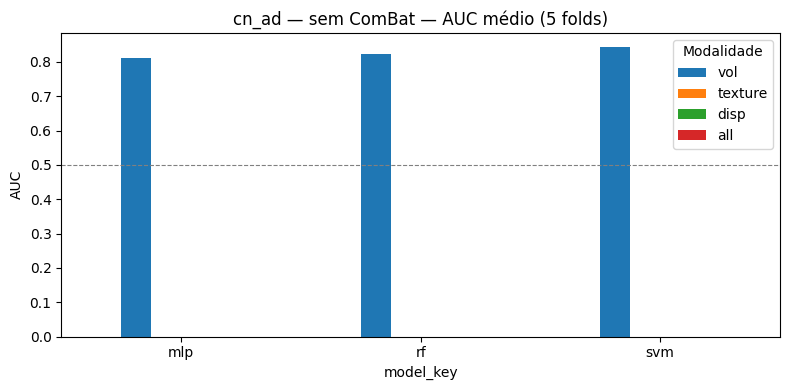

Figura: csvs/longitudinal_4_groups/ablation_results/vol/ablation_auc_cn_ad_nocombat.png


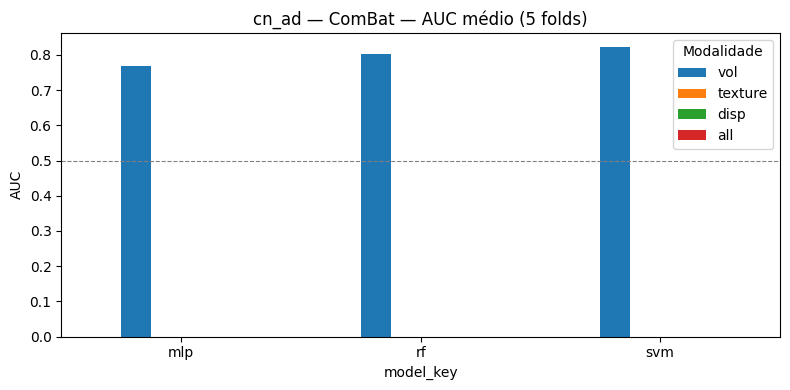

Figura: csvs/longitudinal_4_groups/ablation_results/vol/ablation_auc_cn_ad_combat.png


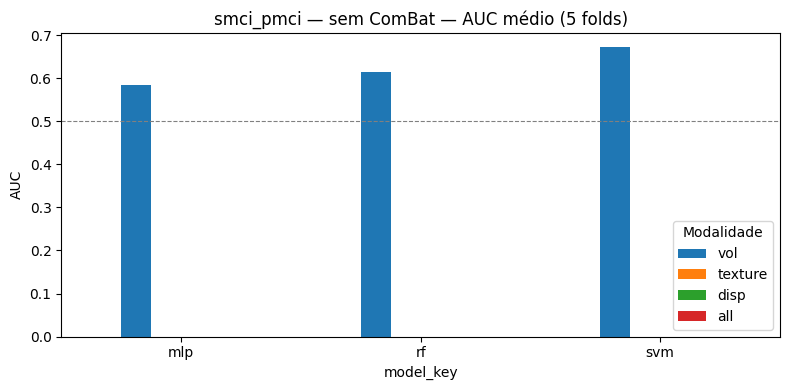

Figura: csvs/longitudinal_4_groups/ablation_results/vol/ablation_auc_smci_pmci_nocombat.png


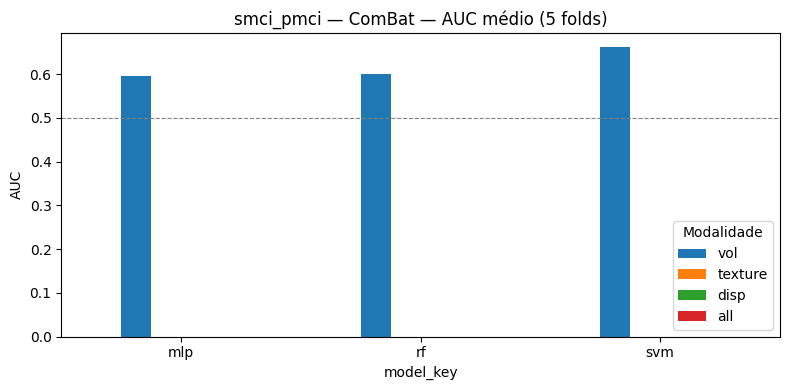

Figura: csvs/longitudinal_4_groups/ablation_results/vol/ablation_auc_smci_pmci_combat.png


In [23]:
# Comparação visual: AUC por task, modalidade e ComBat
mod_order = ["vol", "texture", "disp", "all"]

for task_id in df_ablation["task"].unique():
    sub_task = df_ablation[df_ablation["task"] == task_id]
    for with_combat in sorted(sub_task["with_combat"].unique()):
        sub = sub_task[sub_task["with_combat"] == with_combat]
        pivot_auc = sub.pivot_table(
            index="model_key", columns="modality", values="auc", aggfunc="mean"
        ).reindex(columns=mod_order)

        fig, ax = plt.subplots(figsize=(8, 4))
        pivot_auc.plot(kind="bar", ax=ax, rot=0)
        combat_tag = "ComBat" if with_combat else "sem ComBat"
        ax.set_title(f"{task_id} — {combat_tag} — AUC médio (5 folds)")
        ax.set_ylabel("AUC")
        ax.legend(title="Modalidade")
        ax.axhline(0.5, color="gray", ls="--", lw=0.8)
        plt.tight_layout()
        out = RESULTS_DIR / f"ablation_auc_{task_id}_{'combat' if with_combat else 'nocombat'}.png"
        # plt.savefig(out, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Figura: {out}")

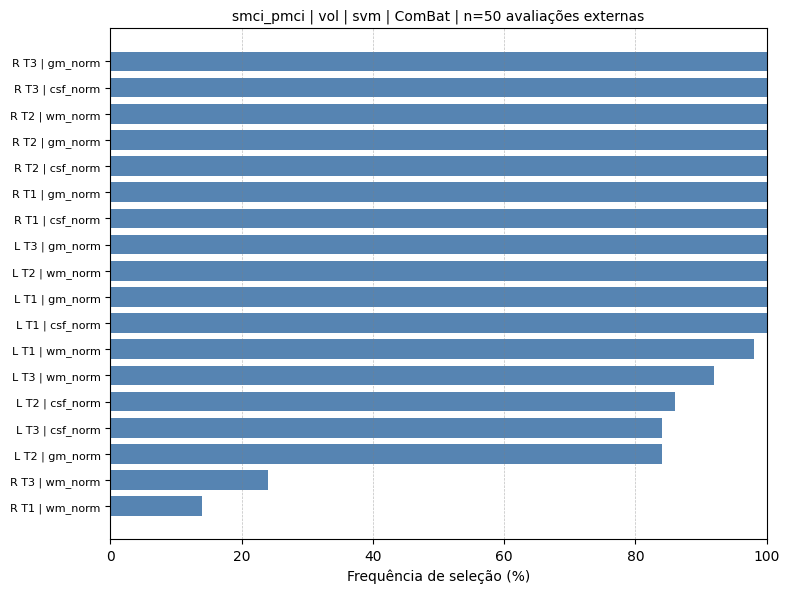

In [24]:
# Estabilidade: frequência de cada atributo (0–100%) por configuração isolada
PLOT_ALL_CONFIGS = False  # True = todas; False = só filtros abaixo
PLOT_TASK = "smci_pmci"
PLOT_MODEL = "svm"
PLOT_COMBAT = True
PLOT_SELECTION = "mrmr"

if PLOT_ALL_CONFIGS:
    plot_specs = [
        (str(t), str(m), str(mk), bool(wc))
        for t in df_ablation["task"].astype(str).unique()
        for m in RUN_MODALITIES
        for mk in MODELS
        for wc in WITH_COMBAT_FLAGS
    ]
else:
    plot_specs = [(PLOT_TASK, MODALITY, PLOT_MODEL, PLOT_COMBAT)]

for task_id, mod_id, model_key, with_combat in plot_specs:
    try:
        df_cfg = filter_ablation_config(
            df_ablation,
            task=task_id,
            modality=mod_id,
            model_key=model_key,
            with_combat=with_combat,
            selection_mode=PLOT_SELECTION,
        )
    except ValueError as exc:
        print(f"Pulando {task_id}/{mod_id}/{model_key}/combat={with_combat}: {exc}")
        continue

    freq = feature_freq_table(df_cfg, top_n=None)
    tag = f"{task_id}_{mod_id}_{model_key}_{'combat' if with_combat else 'nocombat'}"
    # freq_path = RESULTS_DIR / f"feature_freq_{tag}.csv"
    # freq.to_csv(freq_path, index=False)

    fig = plot_feature_stability(df_cfg, out_path=RESULTS_DIR / f"feature_stability_{tag}.png")
    plt.show()
    # print(f"Salvo: {freq_path} ({len(freq)} atributos, n_runs={freq['n_runs'].iloc[0]})")
    plt.close(fig)

# Analise comparativa


import json
import pandas as pd

base = "csvs/longitudinal_4_groups/ablation_results/vol"
s_raw = pd.read_csv(f"{base}/ablation_summary_raw.csv")
s_mrmr = pd.read_csv(f"{base}/ablation_summary_mrmr.csv")
df_m = pd.read_csv(f"{base}/ablation_results_all_mrmr.csv")

# --- PERGUNTA 1: métricas (escolhe UMA config) ---
task, model, combat = "smci_pmci", "svm", True
k = dict(task=task, model_key=model, with_combat=combat)
r = s_raw.merge(s_mrmr, on=["task","modality","model_key","with_combat"], suffixes=("_raw","_mrmr"))
row = r[(r.task==task)&(r.model_key==model)&(r.with_combat==combat)].iloc[0]
print("=== MÉTRICAS ===")
print(f"AUC pooled:  raw={row.auc_pooled_raw:.3f}  mrmr={row.auc_pooled_mrmr:.3f}")
print(f"Features:    raw={row.n_features_mean_raw:.0f}  mrmr={row.n_features_mean_mrmr:.1f}")

# --- PERGUNTA 2: quantos removidos (média) ---
print(f"\nRemovidos (média): {row.n_features_mean_raw - row.n_features_mean_mrmr:.1f} features")

# --- PERGUNTA 3: quais MRMR escolheu (freq entre folds) ---
sub = df_m[(df_m.task==task)&(df_m.model_key==model)&(df_m.with_combat==combat)]
counts = {}
for s in sub["selected_features"]:
    for f in json.loads(s):
        counts[f] = counts.get(f, 0) + 1
n = len(sub)
print(f"\n=== ATRIBUTOS MRMR ({n} avaliações) ===")
for f, c in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {c/n*100:5.1f}%  {f}")

# pool raw (18 vol)
all_raw = set(json.loads(sub.iloc[0]["selected_features"]))  # raw teria 18; pega de mrmr 1ª linha só nomes vol
# melhor: ler uma linha raw
df_r = pd.read_csv(f"{base}/ablation_results_all_raw.csv")
all_raw = set(json.loads(df_r[(df_r.task==task)].iloc[0]["selected_features"]))
never = sorted(all_raw - set(counts))
print(f"\nNUNCA escolhidos pelo MRMR ({len(never)}):")
for f in never:
    print(f"  {f}")